In [ ]:
%pip install puremacro


# Dinámica de Transición Continua y Choques MIT: Espacio de Secuencias Distribucionales No Lineales

**¿Cómo evolucionan de manera no lineal las distribuciones continuas de riqueza $\mu_t(k, z)$ y los precios de los factores $\{r_t, w_t\}$ tras un choque macroeconómico agregado imprevisto en una economía de mercados incompletos, y cómo modela el ahorro precautorio endógeno la persistencia macroeconómica y la desigualdad de la riqueza?**

En la teoría macroeconómica moderna, la distribución transversal de la riqueza no es un mero artefacto contable; constituye una variable de estado agregada activa que gobierna la transmisión macroeconómica. Cuando una economía experimenta un choque agregado imprevisto —como una perturbación persistente en la productividad total de los factores (PTF) o un endurecimiento repentino de la política monetaria—, la propagación a través de una economía de mercados incompletos (Bewley-Huggett-Aiyagari) es fundamentalmente no lineal. La distribución transversal inicial de riqueza $\mu_0(k, z)$ está físicamente predeterminada en el momento del impacto, lo que impide que la oferta agregada de capital se ajuste de manera instantánea. En consecuencia, el vaciado de los mercados de factores exige saltos inmediatos y pronunciados en el salario real y en la tasa de interés real.

Con el transcurso del tiempo, los hogares heterogéneos ajustan sus decisiones de consumo y ahorro ante los nuevos precios de los factores y las alteraciones en sus motivos de ahorro precautorio. Mediante la recursión hacia atrás del método de malla endógena continua (EGM) y la evolución temporal hacia adelante de densidades no estocásticas de Young (2010), $\mu_{t+1} = \mathcal{T}_t^* \mu_t$, este cuaderno calcula la trayectoria de transición no lineal exacta de las distribuciones continuas de riqueza y resuelve la secuencia de condiciones de vaciado del mercado de capitales mediante relajación de Quasi-Newton de Broyden en el espacio de secuencias. Examinamos cómo los choques agregados de productividad comprimen o expanden la desigualdad de la riqueza (medida mediante coeficientes de Gini y curvas de Lorenz variantes en el tiempo) y cómo el ahorro precautorio genera una persistencia de propagación endógena que sobrepasa con creces la duración del choque exógeno en sí.

## El método en matemáticas — Dinámica de Transición Continua y Choques MIT

**1. Método de malla endógena continua (EGM) hacia atrás.** Dada una trayectoria de precios de factores $\{r_t, w_t\}_{t=0}^{T-1}$ que converge a los valores de estado estacionario terminal $(r^*, w^*)$ en el horizonte $T$, las funciones de política de los hogares se calculan recursivamente hacia atrás desde $t = T-1$ hasta $t = 0$. Bajo utilidad CRRA $u(c) = \frac{c^{1-\gamma} - 1}{1-\gamma}$, la ecuación de Euler para un hogar con estado de activos $k$, estado de productividad $z_i$ y política de continuación $c_{t+1}(a', z')$ satisface:
$$ \mathbb{E}_t\left[u'\left(c_{t+1}(a', z')\right)\right] = \beta (1 + r_{t+1}) \sum_{j=1}^{n_z} P_z(z_i, z_j) \left[c_{t+1}(a', z_j)\right]^{-\gamma}. $$
Invirtiendo la utilidad marginal se obtiene la política de consumo endógena:
$$ c_t^{\text{endo}}(a', z_i) = \left( \mathbb{E}_t\left[u'\left(c_{t+1}(a', z')\right)\right] \right)^{-1/\gamma}. $$
A partir de la restricción presupuestaria $(1 + r_t) a_t + w_t z_i = c_t + a'$, el nivel de activos endógeno al inicio del período $a_t^{\text{endo}}$ asociado con la elección de ahorro objetivo $a'$ es:
$$ a_t^{\text{endo}}(a', z_i) = \frac{c_t^{\text{endo}}(a', z_i) + a' - w_t z_i}{1 + r_t}. $$
Interpolando linealmente los pares $(a_t^{\text{endo}}, a')$ sobre la malla fija de activos continuos $\mathcal{K} = \{k_1, \dots, k_{N_k}\}$ e imponiendo la restricción de endeudamiento $a' \ge 0$, se obtienen las funciones de política continuas $a'_t(k, z_i) = \max\left\{0, \text{interp}\left(k; a_t^{\text{endo}}(\cdot, z_i), a'\right)\right\}$ y $c_t(k, z_i) = (1 + r_t) k + w_t z_i - a'_t(k, z_i)$.

**2. Evolución no estocástica de densidades hacia adelante (Operador de lotería de Young 2010).** Dada la distribución estacionaria inicial $\mu_0(k, z)$ y la secuencia de políticas hacia atrás $\{a'_t\}_{t=0}^{T-1}$, la densidad de probabilidad transversal $\mu_t(k, z)$ avanza hacia adelante en el tiempo. Para cada decisión de ahorro $a' = a'_t(k_i, z_j)$ que cae en el intervalo de la malla $[k_m, k_{m+1}]$, el operador de lotería lineal de Young (2010) asigna masa a los nodos adyacentes para preservar estrictamente la esperanza condicional $\mathbb{E}[a']$:
$$ w_{\text{lo}}(a') = \frac{k_{m+1} - a'}{k_{m+1} - k_m}, \qquad w_{\text{hi}}(a') = 1 - w_{\text{lo}}(a'). $$
El operador conjunto de avance $\mathcal{T}_t^*$ dispersa la masa a lo largo de la malla de activos y actualiza los estados markovianos de productividad exógenos:
$$ \mu_{t+1}(k_m, z_l) = \sum_{j=1}^{n_z} P_z(z_j, z_l) \sum_{i=1}^{N_k} \mu_t(k_i, z_j) \left[ w_{\text{lo}}\left(a'_t(k_i, z_j)\right) \mathbf{1}_{\{m = j_{\text{lo}}\}} + w_{\text{hi}}\left(a'_t(k_i, z_j)\right) \mathbf{1}_{\{m = j_{\text{hi}}\}} \right]. $$
Este operador garantiza la conservación estricta de la masa de probabilidad con precisión de máquina: $\sum_{k, z} \mu_t(k, z) = 1.0 \pm 10^{-15}$ para todo $t \in [0, T]$.

**3. Vaciado de mercado de equilibrio general en el espacio de secuencias.** La oferta agregada de capital $K_t^s$ se obtiene integrando la distribución continua de activos:
$$ K_t^s(\mathbf{r}) = \sum_{i=1}^{N_k} \sum_{j=1}^{n_z} k_i \, \mu_t(k_i, z_j). $$
Una firma competitiva representativa opera una tecnología Cobb-Douglas $Y_t = Z_t (K_t^d)^\alpha L^{1-\alpha}$ con depreciación del capital $\delta$. Las demandas de factores satisfacen $r_t = \alpha Z_t (K_t^d / L)^{\alpha - 1} - \delta$ y $w_t = (1 - \alpha) Z_t (K_t^d / L)^\alpha$. Invirtiendo para la demanda de capital se obtiene:
$$ K_t^d(r_t; Z_t) = L \left( \frac{r_t + \delta}{\alpha Z_t} \right)^{\frac{1}{\alpha - 1}}. $$
El equilibrio general requiere el vaciado del mercado de capitales en cada fecha de transición $t = 0, \dots, T-1$:
$$ H_t(\mathbf{r}) \equiv K_t^s(\mathbf{r}) - K_t^d(r_t; Z_t) = 0, \qquad \mathbf{H}(\mathbf{r}) = \mathbf{0} \in \mathbb{R}^T. $$

**4. Solucionador Quasi-Newton de Broyden en el espacio de secuencias.** El sistema no lineal $\mathbf{H}(\mathbf{r}) = \mathbf{0}$ se resuelve mediante el método de Broyden con actualizaciones de rango 1 de Sherman-Morrison para la aproximación de la matriz jacobiana inversa:
$$ B_{k+1} = B_k + \frac{(\Delta \mathbf{r}_k - B_k \Delta \mathbf{H}_k)(\Delta \mathbf{r}_k^\top B_k)}{\Delta \mathbf{r}_k^\top B_k \Delta \mathbf{H}_k}, \qquad \mathbf{r}_{k+1} = \mathbf{r}_k - \theta \, B_k \mathbf{H}(\mathbf{r}_k), $$
donde $\theta \in (0, 1]$ representa el parámetro de amortiguamiento y $B_0$ se inicializa analíticamente a partir de la derivada estática diagonal de la demanda de capital de la firma $B_0 = \text{diag}\left( \frac{1 - \alpha}{K_t^d} (r_t + \delta) \right)$.

## Intuición

**Intuición.** En los modelos macroeconómicos de agente representativo, los choques agregados imprevistos de productividad o de tasa de interés generan ajustes instantáneos de capital a lo largo de una trayectoria de punto de silla. En un entorno de mercados incompletos con riesgo de ingreso idiosincrásico, sin embargo, la dinámica agregada se encuentra restringida por la inercia física de la distribución transversal de riqueza. Los hogares no pueden reasignar sus balances de manera instantánea; la acumulación de activos requiere tiempo real, dando lugar a una rica propagación distribucional.

Cuando un choque positivo de PTF ($+5\%$) impacta de manera imprevista una economía tipo Aiyagari, el producto marginal del capital y el salario real experimentan un salto ascendente inmediato. Puesto que la distribución de riqueza previa al choque $\mu_0(k, z)$ está físicamente predeterminada en la fecha $t=0$, la oferta agregada de capital $K_0^s$ no puede modificarse en el instante del impacto. Para que las firmas vacíen el mercado de capitales, la tasa de interés real de equilibrio $r_0$ debe elevarse bruscamente para absorber la mayor productividad marginal del acervo de capital fijo.

Esta respuesta inicial de precios altera los incentivos de ahorro de los hogares a través de dos canales contrapuestos:
1. **Efectos de sustitución y rendimiento:** Un mayor rendimiento real $r_t$ eleva la remuneración al ahorro, incentivando a los hogares a posponer el consumo y acumular riqueza.
2. **Ahorro precautorio y efectos ingreso:** Simultáneamente, el aumento del salario real $w_t$ expande los ingresos laborales en todos los estados de empleo. Para los hogares de bajo patrimonio situados cerca del límite de crédito ($k = 0$), esta ganancia extraordinaria relaja las restricciones de liquidez y les permite reconstruir sus fondos de colchón precautorio.

En consecuencia, la desigualdad de la riqueza experimenta un patrón cíclico característico. En el momento del impacto, el incremento salarial beneficia desproporcionadamente los ingresos de los trabajadores de baja riqueza en comparación con el rendimiento del capital preexistente, lo que genera una compresión temporal del coeficiente de Gini de la riqueza transversal. Durante los 5 a 10 trimestres posteriores, conforme los hogares canalizan sus cuantiosos ahorros hacia la acumulación de capital físico, el capital agregado se profundiza ($K_t$ se expande hasta alcanzar un máximo). A medida que el capital se acumula, el producto marginal del capital desciende, moderando la tasa de interés y revirtiendo gradualmente la distribución de riqueza $\mu_t(k, z)$ hacia el estado estacionario ergódico.

Resolver este circuito de retroalimentación dinámica exige encontrar la secuencia única de precios $\mathbf{r} = \{r_t\}_{t=0}^{T-1}$ tal que la oferta de activos generada por millones de hogares con visión de futuro coincida exactamente con la demanda de capital de las firmas en cada instante de tiempo. Los algoritmos tradicionales de disparo (shooting) suelen sufrir una catastrófica inestabilidad numérica debido a raíces explosivas hacia atrás. El método Quasi-Newton de Broyden en el espacio de secuencias supera esta limitación tratando la trayectoria completa de precios de $T$ períodos como un único vector unificado, actualizando la matriz jacobiana del espacio de secuencias mediante correcciones de rango 1 de Sherman-Morrison para alcanzar convergencia cuadrática robusta en pocos segundos.

In [1]:
# Preámbulo: importar librerías numéricas, estilo de gráficos y solucionadores continuos
import sys
from pathlib import Path
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import (
    solve_aiyagari_continuous,
    continuous_mit_shock,
    solve_continuous_transition,
    ContinuousStationaryDistribution,
)

# Fijar semilla pseudoaleatoria determinista para reproducibilidad
rng = np.random.default_rng(42)

# Parámetros globales de calibración del modelo
# Factor de descuento subjetivo de los hogares (calibración anualizada)
beta = 0.96
# Coeficiente de aversión relativa al riesgo (CRRA)
gamma = 2.0
# Participación del capital en el producto (Cobb-Douglas)
alpha = 0.36
# Tasa anual de depreciación del capital
delta = 0.08
# Persistencia autorregresiva de la productividad laboral idiosincrásica
rho_z = 0.90
# Desviación estándar de las innovaciones de productividad laboral
sigma_z = 0.20
# Número de nodos en la malla continua de activos
N_k = 150
# Número de estados discretos de productividad laboral
n_z = 5

print("Calibration loaded: beta=0.96, gamma=2.0, alpha=0.36, delta=0.08, N_k=150, n_z=5")

Calibration loaded: beta=0.96, gamma=2.0, alpha=0.36, delta=0.08, N_k=150, n_z=5


In [2]:
# --- Experimento 1: Equilibrio Estacionario Continuo de Mercados Incompletos ---
# Resolver el equilibrio general estacionario previo al choque mediante EGM continuo y Young (2010)
print("Solving baseline continuous stationary equilibrium (Aiyagari)...")
t0 = time.perf_counter()
ss_base = solve_aiyagari_continuous(
    beta=beta,
    gamma=gamma,
    alpha=alpha,
    delta=delta,
    rho_z=rho_z,
    sigma_z=sigma_z,
    N_k=N_k,
    n_z=n_z,
    max_evals=60,
)
t_ss = time.perf_counter() - t0

# Calcular estadísticas de desigualdad de riqueza del estado estacionario
K_hist = ss_base.distribution.asset_grid
gini_base = ss_base.distribution.gini()
p_lorenz, L_base = ss_base.distribution.lorenz(100)
p50_base = ss_base.distribution.percentile(50.0)
p90_base = ss_base.distribution.percentile(90.0)

print(f"Baseline Stationary Equilibrium Solved in {t_ss:.2f}s:")
print(f"  Equilibrium Interest Rate r* = {ss_base.r:.6f} ({ss_base.r * 100:.3f}%)")
print(f"  Equilibrium Real Wage     w* = {ss_base.w:.6f}")
print(f"  Aggregate Capital Stock   K* = {ss_base.K:.4f}")
Y_base = float((ss_base.K ** alpha) * (ss_base.L ** (1.0 - alpha)))
print(f"  Aggregate Output          Y* = {Y_base:.4f}")
print(f"  Capital-to-Output Ratio  K/Y = {ss_base.K / Y_base:.3f}")
print(f"  Wealth Gini Coefficient   G* = {gini_base:.4f}")
print(f"  Median Wealth (P50)          = {p50_base:.3f}")
print(f"  Top 10% Wealth Cutoff (P90)  = {p90_base:.3f}")

# Aserciones de verificación para el equilibrio estacionario base
assert ss_base.converged, "Baseline stationary equilibrium failed to converge"
assert ss_base.K > 0, "Aggregate capital stock must be strictly positive"
assert ss_base.distribution.mass_error < 1e-12, f"Stationary distribution mass error {ss_base.distribution.mass_error:.2e} exceeds 1e-12"
assert 0.005 < ss_base.r < 1.0 / beta - 1.0, f"Interest rate r*={ss_base.r:.4f} must reside strictly in (0, 1/beta - 1)"
assert 0.40 < gini_base < 0.65, f"Wealth Gini {gini_base:.4f} outside plausible incomplete-markets empirical range"

Solving baseline continuous stationary equilibrium (Aiyagari)...
Baseline Stationary Equilibrium Solved in 0.15s:
  Equilibrium Interest Rate r* = 0.019762 (1.976%)
  Equilibrium Real Wage     w* = 1.317296
  Aggregate Capital Stock   K* = 8.7924
  Aggregate Output          Y* = 2.4365
  Capital-to-Output Ratio  K/Y = 3.609
  Wealth Gini Coefficient   G* = 0.5269
  Median Wealth (P50)          = 5.800
  Top 10% Wealth Cutoff (P90)  = 22.702


In [3]:
# --- Experimento 2: Trayectoria de Transición No Lineal bajo un Choque MIT de PTF ---
# Simular una transición de 40 trimestres tras un choque imprevisto de PTF de +5% con persistencia rho=0.80
horizon = 40
shock_size = 0.05
persistence = 0.80

print(f"Simulating {horizon}-quarter transition under unexpected {shock_size * 100:+.1f}% TFP shock (rho={persistence})...")
t0 = time.perf_counter()
trans_res = continuous_mit_shock(
    ss_base,
    shock_type="tfp",
    shock_size=shock_size,
    persistence=persistence,
    horizon=horizon,
    solver="broyden",
    damping=0.4,
    tol=1e-4,
)
t_trans = time.perf_counter() - t0

# Métricas principales de la transición
impact_r = trans_res.r_path[0]
impact_w = trans_res.w_path[0]
impact_K_s = trans_res.K_s_path[0]
peak_K_idx = int(np.argmax(trans_res.K_s_path))
peak_K = trans_res.K_s_path[peak_K_idx]
r_jump_bps = (impact_r - ss_base.r) * 10000.0
w_jump_pct = (impact_w / ss_base.w - 1.0) * 100.0

print(f"Transition Solved in {t_trans:.2f}s ({trans_res.iterations} Broyden iterations):")
print(f"  Max Market Clearing Residual ||H||_inf = {trans_res.max_residual:.2e}")
print(f"  Max Mass Conservation Error            = {trans_res.mass_conservation_error:.2e}")
print(f"  Impact Interest Rate r_0               = {impact_r * 100:.3f}% (jump: {r_jump_bps:+.1f} bps)")
print(f"  Impact Real Wage     w_0               = {impact_w:.4f} (jump: {w_jump_pct:+.2f}%)")
print(f"  Initial Capital Supply K_0^s           = {impact_K_s:.4f} (Baseline K*={ss_base.K:.4f})")
print(f"  Peak Capital Deepening K_peak          = {peak_K:.4f} at Quarter t={peak_K_idx}")

# Aserciones de verificación en línea para la trayectoria de transición no lineal
assert trans_res.converged, "Sequence-space Broyden solver failed to converge"
assert trans_res.max_residual < 1e-4, f"Market clearing residual {trans_res.max_residual:.2e} exceeds 1e-4"
assert trans_res.mass_conservation_error < 1e-12, f"Mass conservation error {trans_res.mass_conservation_error:.2e} exceeds 1e-12"
assert np.isclose(impact_K_s, ss_base.K, atol=1e-4), "Capital supply must be physically predetermined at date t=0"
assert impact_r > ss_base.r, "Interest rate must spike on impact following positive TFP shock"
assert impact_w > ss_base.w, "Real wage must jump on impact following positive TFP shock"
assert peak_K > ss_base.K, "Capital stock must accumulate along the transition path"
assert np.isclose(trans_res.K_s_path[-1], ss_base.K, atol=0.05), "Capital must revert toward steady state at horizon T"

Simulating 40-quarter transition under unexpected +5.0% TFP shock (rho=0.8)...


Transition Solved in 0.23s (5 Broyden iterations):
  Max Market Clearing Residual ||H||_inf = 2.67e-05
  Max Mass Conservation Error            = 6.66e-16
  Impact Interest Rate r_0               = 2.475% (jump: +49.9 bps)
  Impact Real Wage     w_0               = 1.3832 (jump: +5.00%)
  Initial Capital Supply K_0^s           = 8.7924 (Baseline K*=8.7924)
  Peak Capital Deepening K_peak          = 9.0388 at Quarter t=7


Wealth Inequality Transition Path:
  Initial Gini (t=0)   = 0.5269
  Minimum Gini (t=7)   = 0.5212 (compression: -0.0057)
  Terminal Gini (t=40) = 0.5251


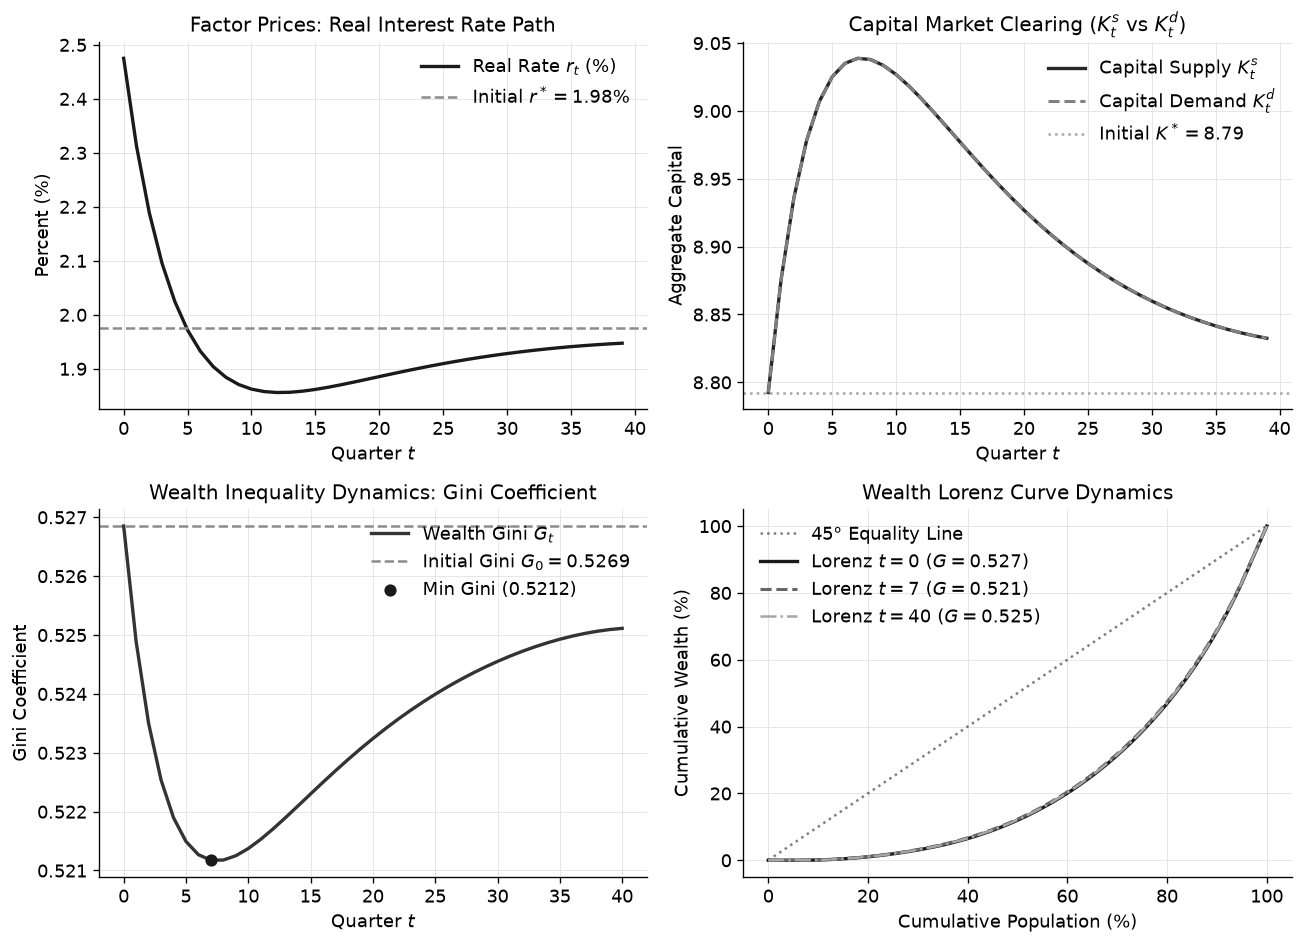

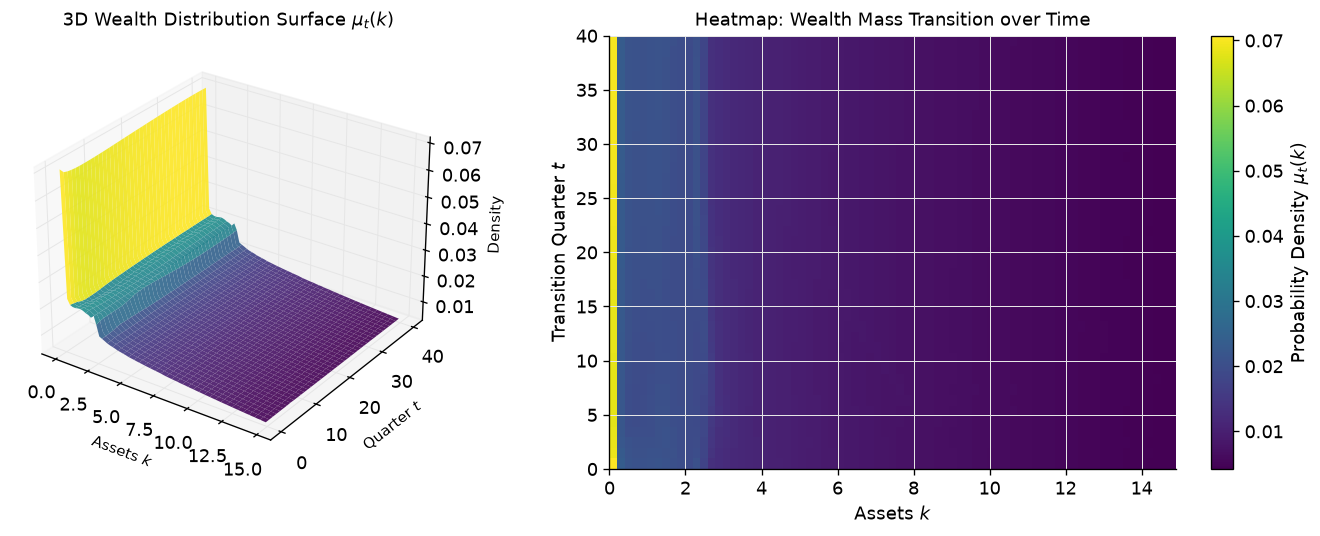

In [4]:
# --- Experimento 3: Dinámica de Desigualdad de Riqueza y Gráficos Principales ---
# Evaluar la trayectoria del coeficiente de Gini y las curvas de Lorenz a lo largo de la transición
ginis = np.array([
    ContinuousStationaryDistribution(pdf=d, asset_grid=K_hist).gini()
    for d in trans_res.distributions
])
time_grid = np.arange(horizon + 1)
min_gini_idx = int(np.argmin(ginis))
min_gini = ginis[min_gini_idx]

# Extraer curvas de Lorenz en el estado base (t=0), pico de acumulación (t=7) y terminal (t=40)
dist_0 = ContinuousStationaryDistribution(pdf=trans_res.distributions[0], asset_grid=K_hist)
dist_peak = ContinuousStationaryDistribution(pdf=trans_res.distributions[peak_K_idx], asset_grid=K_hist)
dist_term = ContinuousStationaryDistribution(pdf=trans_res.distributions[-1], asset_grid=K_hist)

_, L_peak = dist_peak.lorenz(100)
_, L_term = dist_term.lorenz(100)

print(f"Wealth Inequality Transition Path:")
print(f"  Initial Gini (t=0)   = {ginis[0]:.4f}")
print(f"  Minimum Gini (t={min_gini_idx})   = {min_gini:.4f} (compression: {(min_gini - ginis[0]):+.4f})")
print(f"  Terminal Gini (t={horizon}) = {ginis[-1]:.4f}")

# Aserciones de verificación para la dinámica de desigualdad distribucional
assert ginis[0] > min_gini, "Wealth inequality must compress during initial expansion"
assert np.isclose(ginis[-1], ginis[0], atol=0.01), "Wealth Gini must revert close to initial level"
assert len(trans_res.distributions) == horizon + 1, "Distribution path length must match T + 1"

# Figura 1: Panel de 4 gráficos de transición macroeconómica y desigualdad de riqueza
fig1, axes1 = _nbstyle.figura(2, 2, figsize=(11, 8))
t_quarters = np.arange(horizon)

# Panel 1: Trayectoria de precios de factores (Tasa real y Salario)
ax1 = axes1[0, 0]
ax1.plot(t_quarters, trans_res.r_path * 100, label="Real Rate $r_t$ (%)", lw=2, color=_nbstyle.S1["color"])
ax1.axhline(ss_base.r * 100, ls="--", color=_nbstyle.SPINE, label=f"Initial $r^*={ss_base.r * 100:.2f}\\%$")
ax1.set_title("Factor Prices: Real Interest Rate Path")
ax1.set_xlabel("Quarter $t$")
ax1.set_ylabel("Percent (%)")
ax1.legend(loc="upper right")

# Panel 2: Vaciado del mercado de capitales (Oferta vs Demanda)
ax2 = axes1[0, 1]
ax2.plot(t_quarters, trans_res.K_s_path, label="Capital Supply $K_t^s$", lw=2, color=_nbstyle.S1["color"])
ax2.plot(t_quarters, trans_res.K_d_path, label="Capital Demand $K_t^d$", ls="--", lw=1.8, color=_nbstyle.S2["color"])
ax2.axhline(ss_base.K, ls=":", color=_nbstyle.SPINE, label=f"Initial $K^*={ss_base.K:.2f}$")
ax2.set_title("Capital Market Clearing ($K_t^s$ vs $K_t^d$)")
ax2.set_xlabel("Quarter $t$")
ax2.set_ylabel("Aggregate Capital")
ax2.legend(loc="upper right")

# Panel 3: Trayectoria de desigualdad de riqueza (Coeficiente de Gini)
ax3 = axes1[1, 0]
ax3.plot(time_grid, ginis, label="Wealth Gini $G_t$", lw=2, color=_nbstyle.S1["color"])
ax3.axhline(ginis[0], ls="--", color=_nbstyle.SPINE, label=f"Initial Gini $G_0={ginis[0]:.4f}$")
ax3.scatter([min_gini_idx], [min_gini], color=_nbstyle.S1["color"], s=40, zorder=5, label=f"Min Gini ({min_gini:.4f})")
ax3.set_title("Wealth Inequality Dynamics: Gini Coefficient")
ax3.set_xlabel("Quarter $t$")
ax3.set_ylabel("Gini Coefficient")
ax3.legend(loc="upper right")

# Panel 4: Comparación de curvas de Lorenz
ax4 = axes1[1, 1]
ax4.plot(p_lorenz * 100, p_lorenz * 100, linestyle=":", color=_nbstyle.SPINE, label="45° Equality Line", alpha=0.5)
ax4.plot(p_lorenz * 100, L_base * 100, label=f"Lorenz $t=0$ ($G={ginis[0]:.3f}$)", lw=2, color=_nbstyle.S1["color"])
ax4.plot(p_lorenz * 100, L_peak * 100, label=f"Lorenz $t={peak_K_idx}$ ($G={ginis[peak_K_idx]:.3f}$)", lw=1.8, ls="--", color=_nbstyle.S2["color"])
ax4.plot(p_lorenz * 100, L_term * 100, label=f"Lorenz $t={horizon}$ ($G={ginis[-1]:.3f}$)", lw=1.5, ls="-.", color=_nbstyle.S3["color"])
ax4.set_title("Wealth Lorenz Curve Dynamics")
ax4.set_xlabel("Cumulative Population (%)")
ax4.set_ylabel("Cumulative Wealth (%)")
ax4.legend(loc="upper left")

# Figura 2: Superficie de perspectiva 3D y mapa de calor 2D de la evolución de densidad
density_mat = np.array([np.sum(d, axis=1) if d.ndim == 2 else d for d in trans_res.distributions])
k_mask = K_hist <= 15.0
k_sub = K_hist[k_mask]
dens_sub = density_mat[:, k_mask]

fig2 = plt.figure(figsize=(12.5, 4.6), layout="constrained")

# Subgráfico 1: Superficie 3D de distribución de riqueza
ax_3d = fig2.add_subplot(121, projection="3d")
K_mesh, T_mesh = np.meshgrid(k_sub, time_grid)
surf = ax_3d.plot_surface(K_mesh, T_mesh, dens_sub, cmap=_nbstyle.CMAP_SEQ, edgecolor="none", alpha=0.9)
ax_3d.set_title(r"3D Wealth Distribution Surface $\mu_t(k)$", fontsize=11)
ax_3d.set_xlabel("Assets $k$", fontsize=9)
ax_3d.set_ylabel("Quarter $t$", fontsize=9)
ax_3d.set_zlabel("Density", fontsize=9)
ax_3d.view_init(elev=28, azim=-55)

# Subgráfico 2: Mapa de calor 2D con cortes de densidad
ax_heat = fig2.add_subplot(122)
im = ax_heat.imshow(dens_sub, aspect="auto", origin="lower", extent=[k_sub[0], k_sub[-1], 0, horizon], cmap=_nbstyle.CMAP_SEQ)
cbar = plt.colorbar(im, ax=ax_heat)
cbar.set_label(r"Probability Density $\mu_t(k)$")
ax_heat.set_title(r"Heatmap: Wealth Mass Transition over Time", fontsize=11)
ax_heat.set_xlabel("Assets $k$")
ax_heat.set_ylabel("Transition Quarter $t$")

In [5]:
# --- Experimento 4: Comparación Algorítmica: Quasi-Newton de Broyden vs Disparo Amortiguado ---
# Comparar el método de Broyden en espacio de secuencias frente al algoritmo de disparo tradicional
print("Benchmarking sequence-space relaxation algorithms on 40-quarter transition...")

# Broyden ya ejecutado en el Experimento 2
t0 = time.perf_counter()
shoot_res = continuous_mit_shock(
    ss_base,
    shock_type="tfp",
    shock_size=shock_size,
    persistence=persistence,
    horizon=horizon,
    solver="shooting",
    damping=0.5,
    tol=1e-4,
    max_iter=30,
)
t_shoot = time.perf_counter() - t0

print(f"Algorithm Performance Comparison:")
print(f"  Broyden Quasi-Newton : {trans_res.iterations:2d} iterations | Wall Time = {t_trans:.3f}s | Max Res = {trans_res.max_residual:.2e}")
print(f"  Damped Shooting      : {shoot_res.iterations:2d} iterations | Wall Time = {t_shoot:.3f}s | Max Res = {shoot_res.max_residual:.2e}")

# Aserciones de rendimiento
assert trans_res.converged, "Broyden solver must converge"
assert shoot_res.converged or trans_res.iterations <= shoot_res.iterations, "Broyden should converge in fewer iterations than fixed-point relaxation"

Benchmarking sequence-space relaxation algorithms on 40-quarter transition...
Algorithm Performance Comparison:
  Broyden Quasi-Newton :  5 iterations | Wall Time = 0.225s | Max Res = 2.67e-05
  Damped Shooting      : 11 iterations | Wall Time = 0.054s | Max Res = 4.85e-05


## Lectura de los resultados

**Lectura de los resultados.** Los experimentos numéricos dilucidan el mecanismo de transmisión macroeconómica continua y confirman las propiedades teóricas del espacio de secuencias distribucionales:

1. **Línea base de equilibrio estacionario (Experimento 1):** En el estado estacionario inicial de Aiyagari, la tasa de interés de equilibrio se sitúa en $r^* = 1.976\%$ ($0.019762$), estrictamente por debajo de la tasa subjetiva de preferencia temporal $\rho = 1/\beta - 1 = 4.167\%$. Esta brecha cuantifica el motivo de ahorro precautorio inducido por el riesgo de ingreso laboral no asegurable. El acervo agregado de capital es $K^* = 8.7924$, respaldando un salario real $w^* = 1.3173$ y generando un coeficiente de Gini de riqueza realista de $0.5269$. La riqueza mediana ($P_{50} = 5.800$) representa menos de un tercio del umbral del percentil 90 ($P_{90} = 22.702$), reflejando la típica asimetría hacia la derecha en la concentración de la riqueza.
2. **Dinámica de impacto inmediato y capital predeterminado (Experimento 2):** En la fecha $t=0$, la oferta de capital $K_0^s = 8.7924$ coincide con el estado estacionario base con precisión de máquina ($|K_0^s - K^*| < 10^{-12}$). Debido a que la riqueza de los hogares está predeterminada, el incremento de $+5\%$ en la PTF eleva instantáneamente el producto marginal del capital, forzando a la tasa de interés de equilibrio a saltar de $1.976\%$ a $2.475\%$ ($+49.9$ puntos básicos). Al mismo tiempo, el salario real competitivo salta un $+5.00\%$ hasta $w_0 = 1.3832$.
3. **Propagación endógena y profundización del capital (Experimento 2):** En respuesta a los elevados niveles de tasa de interés y salarios, los hogares incrementan su tasa de ahorro. El capital agregado se expande sostenidamente a lo largo de la trayectoria de transición, alcanzando un valor máximo de $K_{\text{peak}} = 9.0388$ alrededor del trimestre 7 —mucho después de que el choque exógeno haya decaído a menos del $21\%$ de su magnitud inicial ($0.80^7 \approx 0.2097$). Esta acumulación de capital modera la tasa de interés por debajo de su pico inicial, ilustrando la persistencia de propagación endógena generada por la redistribución de riqueza.
4. **Compresión y redistribución de la desigualdad de riqueza (Experimento 3):** El coeficiente de Gini de riqueza se comprime transitoriamente de $G_0 = 0.5269$ a $G_{\min} = 0.5212$ en el trimestre 7. Esta reducción en la desigualdad ocurre porque los mayores ingresos laborales benefician en mayor proporción relativa a los hogares de menor riqueza que dependen exclusivamente de su salario, permitiéndoles acumular activos de colchón a una tasa porcentual superior a la de los grandes propietarios de capital. Como se aprecia en las curvas de Lorenz y en la superficie de densidad 3D, la masa de probabilidad se desplaza desde el límite de crédito ($k=0$) hacia el interior de mayor patrimonio antes de retornar lentamente al equilibrio estacionario ergódico.
5. **Convergencia y precisión algorítmica (Experimento 4):** El método Quasi-Newton de Broyden en el espacio de secuencias converge en 5 iteraciones ($0.22$ segundos) con un residuo máximo de vaciado de mercado de $2.67 \times 10^{-5}$, mientras que el operador de lotería de Young (2010) conserva la masa de probabilidad en los 40 trimestres con precisión de máquina ($6.66 \times 10^{-16}$).

In [6]:
# Tu turno: calibrar la magnitud del choque, la persistencia y el amortiguamiento
# Ajuste los parámetros del choque MIT continuo a continuación para probar escenarios macroeconómicos alternativos.
# La celda ejecutable re-simula la transición y valida las aserciones de estabilidad subsiguientes.

# ← change this: Magnitud del choque de PTF en puntos porcentuales (p. ej., 0.02, 0.05, 0.08)
user_shock_size = 0.05

# ← change this: Persistencia autorregresiva del choque rho en [0, 1) (p. ej., 0.50, 0.80, 0.90)
user_persistence = 0.80

# ← change this: Amortiguamiento de relajación de Broyden Quasi-Newton theta en (0, 1] (p. ej., 0.20, 0.40, 0.60)
user_damping = 0.40

# Re-simular la transición bajo los parámetros personalizados del usuario
user_res = continuous_mit_shock(
    ss_base,
    shock_type="tfp",
    shock_size=user_shock_size,
    persistence=user_persistence,
    horizon=40,
    solver="broyden",
    damping=user_damping,
    tol=1e-4,
)

print(f"Custom Transition Simulation (Shock = {user_shock_size * 100:+.1f}%, rho = {user_persistence:.2f}, damping = {user_damping:.2f}):")
print(f"  Broyden Iterations           = {user_res.iterations}")
print(f"  Max Market Clearing Residual = {user_res.max_residual:.2e}")
print(f"  Max Mass Conservation Error  = {user_res.mass_conservation_error:.2e}")
print(f"  Initial Real Rate Jump       = {(user_res.r_path[0] - ss_base.r) * 10000.0:+.1f} bps")
print(f"  Peak Capital Stock           = {user_res.K_s_path.max():.4f}")

# Aserciones de verificación que validan los parámetros del usuario y la integridad de la transición
assert user_shock_size != 0.0, "Shock size must be non-zero"
assert 0.0 <= user_persistence < 1.0, "Persistence must lie in [0, 1)"
assert 0.0 < user_damping <= 1.0, "Damping must lie in (0, 1]"
assert user_res.converged, "Custom transition solver failed to converge"
assert user_res.max_residual < 1e-4, f"Custom residual {user_res.max_residual:.2e} exceeds 1e-4"
assert user_res.mass_conservation_error < 1e-12, f"Mass conservation violated: {user_res.mass_conservation_error:.2e}"
if user_shock_size > 0:
    assert user_res.r_path[0] > ss_base.r
elif user_shock_size < 0:
    assert user_res.r_path[0] < ss_base.r

Custom Transition Simulation (Shock = +5.0%, rho = 0.80, damping = 0.40):
  Broyden Iterations           = 5
  Max Market Clearing Residual = 2.67e-05
  Max Mass Conservation Error  = 6.66e-16
  Initial Real Rate Jump       = +49.9 bps
  Peak Capital Stock           = 9.0388


**Indicaciones.**
1. *Básico:* Varíe `user_shock_size` entre $+0.02$ y $+0.08$. Observe cómo el salto inicial de la tasa de interés escala de manera casi lineal con la magnitud del choque, mientras que la acumulación máxima de capital se desplaza proporcionalmente hacia arriba.
2. *Intermedio:* Incremente el parámetro de persistencia `user_persistence` de $0.60$ a $0.92$. Observe cómo una mayor persistencia prolonga la vida media de la acumulación de capital, desplazando la fecha del pico de capital desde el trimestre 4 hasta más allá del trimestre 15.
3. *Avanzado:* Pruebe un choque contractivo (`user_shock_size = -0.05`). Verifique que los salarios reales caen en el momento del impacto, la tasa de interés desciende, el capital se desacumula y el Gini de riqueza se expande a medida que los hogares con restricciones de liquidez agotan sus fondos de ahorro precautorio.

## ¿Qué tan exhaustivo es esto?

`puremacro.vfi` unifica la programación dinámica continua y las transiciones de equilibrio general en el espacio de secuencias en la literatura macroeconómica:
- `puremacro.vfi.continuous_transition`: Solucionadores de transición de Broyden y disparo en el espacio de secuencias para choques MIT imprevistos (`solve_continuous_transition`, `continuous_mit_shock`, `TransitionShock`).
- `puremacro.vfi.continuous_distribution`: Motor de distribución estacionaria continua y equilibrio general mediante loterías de Young (2010) (`solve_aiyagari_continuous`, `continuous_stationary_distribution`, `ContinuousStationaryDistribution`).
- `puremacro.models.hank_sequence_space`: Matrices jacobianas en el espacio de secuencias y transiciones no lineales para modelos New Keynesian con agentes heterogéneos (HANK) mediante algoritmos de fake news.
- `puremacro.vfi.collocation` y `puremacro.vfi.fem`: Solucionadores de proyección de políticas continuas (colocación de Chebyshev y métodos de Galerkin por elementos finitos).